# Running Cy2path on control datasets

***

Jan T. Schleicher, 2025

Here, we run Cy2path on simulated data with known ground truth trajectories as a positive control.
We use dyngen-generated data of a bifurcation process.
Additionally, we use a dataset of peripheral blood mononuclear cells (PBMC) as a negatice control as there should not be any trajectories between the distrinct cell types in this type of data.

In [1]:
import os

import cy2path as c2p
import numpy as np
import scanpy as sc
import scvelo as scv
import torch
from matplotlib import pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

## Negative control

PBMC dataset with distinct cell types.

In [2]:
adata_pbmc = scv.datasets.pbmc68k()
adata_pbmc

AnnData object with n_obs × n_vars = 65877 × 33939
    obs: 'celltype'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    obsm: 'X_tsne'
    layers: 'spliced', 'unspliced'

In [3]:
# Preprocessing
scv.pp.filter_and_normalize(adata_pbmc, min_shared_counts=20, n_top_genes=2000)
sc.pp.scale(adata_pbmc)
sc.pp.pca(adata_pbmc)
sc.pp.neighbors(adata_pbmc, n_neighbors=30)
scv.pp.moments(adata_pbmc, n_pcs=50, n_neighbors=30)
sc.tl.umap(adata_pbmc)

Filtered out 33338 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Skip filtering by dispersion since number of variables are less than `n_top_genes`.
Logarithmized X.


/Users/janschleicher/miniconda3/envs/cytopath/lib/python3.9/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [4]:
# Estimate RNA velocity
scv.tl.velocity(adata_pbmc)
scv.tl.velocity_graph(adata_pbmc, mode_neighbors="connectivities")
scv.tl.terminal_states(adata_pbmc)
adata_pbmc.obsp["T_forward"] = scv.utils.get_transition_matrix(
    adata_pbmc, self_transitions=False
)

computing velocities


/Users/janschleicher/miniconda3/envs/cytopath/lib/python3.9/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:01) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/10 cores)


  0%|          | 0/65877 [00:00<?, ?cells/s]

    finished (0:00:10) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing terminal states
    identified 2 regions of root cells and 2 regions of end points .
    finished (0:00:02) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


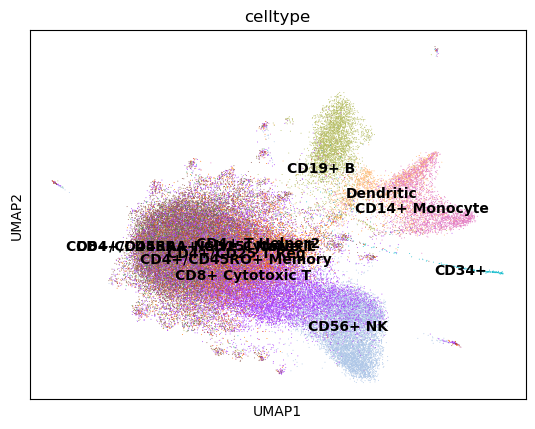

In [5]:
# Plot the cell types on the UMAP
sc.pl.umap(adata_pbmc, color="celltype", legend_loc="on data")

computing velocity embedding
    finished (0:00:04) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/Users/janschleicher/miniconda3/envs/cytopath/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/janschleicher/miniconda3/envs/cytopath/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/janschleicher/miniconda3/envs/cytopath/lib/python3.9/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/Users/janschleicher/minicon

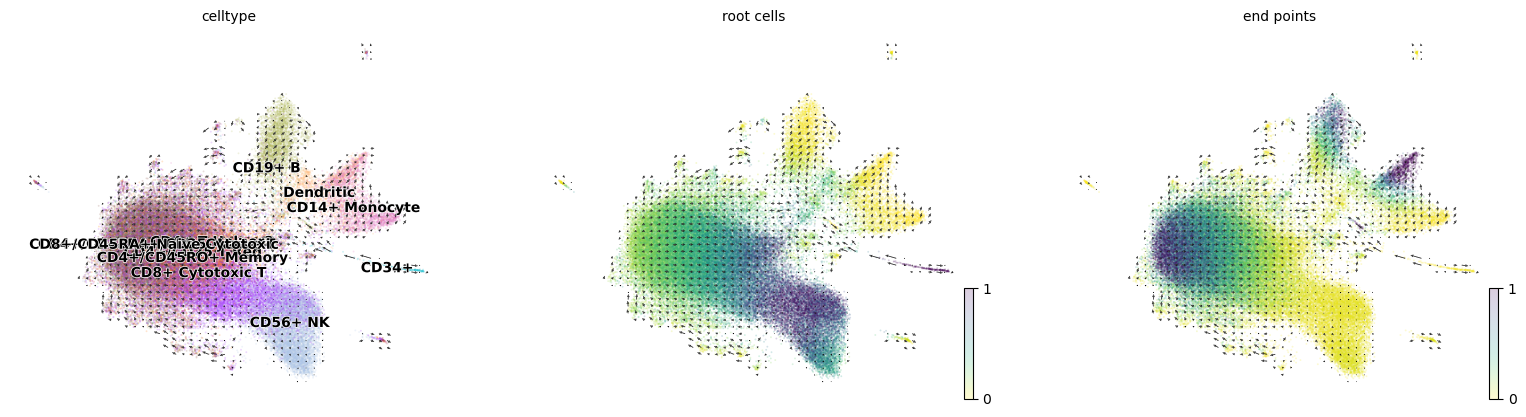

In [6]:
# Plot velocities
scv.pl.velocity_embedding_grid(
    adata_pbmc,
    color=["celltype", "root_cells", "end_points"],
    basis="umap",
    legend_loc="on data",
)

In [8]:
c2p.sample_state_probability(adata_pbmc, recalc_matrix=False, tol=1e-4)

Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

In [9]:
# Run cy2path analysis
c2p.infer_cytopath_lineages(
    adata_pbmc,
    method="linkage",
    recalc_matrix=False,
    num_chains=1000,
    num_lineages="auto",
    max_lineages=6,
    n_jobs=-1,
)

INFO:root:Using precomputed state probability sampling
INFO:root:Sampling Markov chains


Iterating Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Storing Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Computing empirical state probability distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Clustering the samples.
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)


Finding optimal number of lineages between 2 and 6:   0%|          | 0/5 [00:00<?, ?it/s]

INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:root:Optimal number of lineages is 2 with silhouette score 0.567


Computing coordinates:   0%|          | 0/2 [00:00<?, ? lineage/s]

<Axes: >

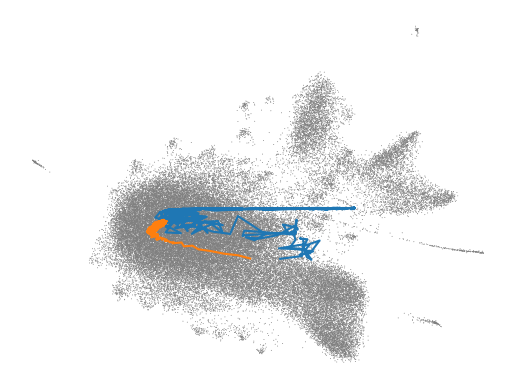

In [10]:
c2p.plot_cytopath_lineages(adata_pbmc, basis="umap")

In [13]:
adata_pbmc.uns["cytopath"]["silhouette_scores"] = {
    str(key): val
    for key, val in adata_pbmc.uns["cytopath"]["silhouette_scores"].items()
}
adata_pbmc.write_h5ad("../data/adata_pbmc.h5ad", compression="gzip")

## Alternative negative control: permuted transition probability matrix

We use the T cell exhaustion data to generate a scrambled transition probability matrix.
This acts as another negative control setting.

In [22]:
# Load the data
adata = sc.read_h5ad("../data/tex_data_chronic_annotated.h5ad")
adata

AnnData object with n_obs × n_vars = 13410 × 7170
    obs: 'sampleID', 'barcode', 'sample_type', 'timepoint', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mitochondrial', 'log1p_total_counts_mitochondrial', 'pct_counts_mitochondrial', 'total_counts_ribosomal', 'log1p_total_counts_ribosomal', 'pct_counts_ribosomal', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_genes', 'n_counts', 'phase', 'S_score', 'G2M_score', 'score_diff', 'leiden', 'velocity_self_transition', 'root_cells', 'end_points', 'velocity_pseudotime', 'latent_time', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'annot'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'mitochondrial', 'ribosomal', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'cell_cycle_genes', 'gene_count_corr', 'means', 'dispersions',

In [30]:
# Permute the rows of the TPM
rng = np.random.default_rng(42)
permutation = rng.permutation(adata.shape[0])
tpm = adata.uns["T_forward"].copy().toarray()[permutation, :]

# Individually permute the columns of the TPM for each row
for i, row in enumerate(tpm):
    permutation_row = rng.permutation(row.shape[0])
    tpm[i, :] = row[permutation_row]
adata.obsp["T_forward"] = tpm

In [31]:
# Perform state probability sampling to find the number of steps
c2p.sample_state_probability(adata, recalc_matrix=False)

Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Tolerance reached after 5 iterations of 1000.


In [32]:
# Run cy2path analysis
c2p.infer_cytopath_lineages(
    adata,
    method="linkage",
    recalc_matrix=False,
    recalc_items=True,
    num_chains=1000,
    num_lineages="auto",
    max_lineages=6,
    n_jobs=-1,
)

Iterating state probability distributions:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Tolerance reached after 5 iterations of 1000.
INFO:root:Sampling Markov chains


Iterating Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.
Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


Storing Markov chains:   0%|          | 0/1000 [00:00<?, ? simulations/s]

Computing empirical state probability distribution:   0%|          | 0/1000 [00:00<?, ?it/s]

INFO:root:Clustering the samples.
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)


Finding optimal number of lineages between 2 and 6:   0%|          | 0/5 [00:00<?, ?it/s]

INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:be.kuleuven.dtai.distance:Computing distances
INFO:be.kuleuven.dtai.distance:Compute distances in C (parallel=OMP)
INFO:root:Optimal number of lineages is 3 with silhouette score 0.114


Computing coordinates:   0%|          | 0/3 [00:00<?, ? lineage/s]

<Axes: >

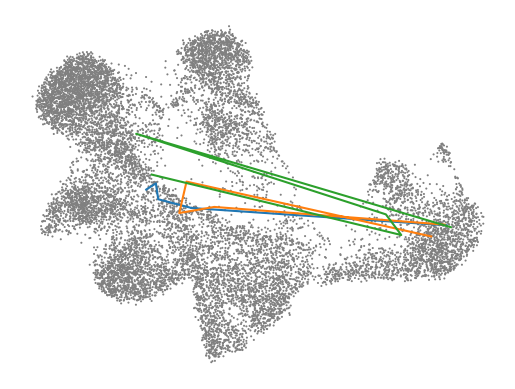

In [33]:
c2p.plot_cytopath_lineages(adata)